# RL Experiment Plots

Visualize training metrics from RL experiments across three settings:
- `real_world`
- `simulation`
- `simulation_with_real_world_input`

Metrics: `ep_len_mean`, `ep_rew_mean`, `top_score`

In [226]:
from tbparse import SummaryReader
import pandas as pd
import os
import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import plot_functions
importlib.reload(plot_functions)
from plot_functions import plot_learning_curves

import style
importlib.reload(style)
from style import MatplotlibStyle

mpl_style = MatplotlibStyle()
mpl_style.apply()

In [227]:
def load_hns_scores(files_dict: dict, random_score: float, human_score: float) -> dict:
    """
    Load episode-score arrays from .npz files and convert to Human Normalized Score.

    Args:
        files_dict:   dict mapping label -> path to .npz file containing key 'array'.
        random_score: random-agent baseline score for the game.
        human_score:  human reference score for the game.

    Returns:
        dict mapping label -> 1-D numpy array of HNS values.
    """
    hns = {}
    for label, path in files_dict.items():
        raw = np.load(path)['array'].astype(float)
        hns[label] = (raw - random_score) / (human_score - random_score)
    return hns


In [228]:
from scipy.stats import bootstrap as _scipy_bootstrap


# ── Helper statistics ────────────────────────────────────────────────────────
def _iqm(x):
    """Interquartile Mean: mean of scores in the [Q25, Q75] range."""
    q25, q75 = np.percentile(x, [25, 75])
    return np.mean(x[(x >= q25) & (x <= q75)])


def _bootstrap_ci(data, stat_fn, n_resamples=10_000, ci=0.95, seed=0):
    """Return (point_estimate, ci_low, ci_high) via percentile bootstrap."""
    result = _scipy_bootstrap(
        (data,), stat_fn,
        n_resamples=n_resamples,
        confidence_level=ci,
        method='percentile',
        random_state=seed,
    )
    return stat_fn(data), result.confidence_interval.low, result.confidence_interval.high


# ── Plotting function ────────────────────────────────────────────────────────
def plot_interval_estimates(
    hns_scores,
    metric='Median',
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    _STAT_FNS = {'Median': np.median, 'IQM': _iqm, 'Mean': np.mean}
    if metric not in _STAT_FNS:
        raise ValueError(f"metric must be one of {list(_STAT_FNS.keys())}, got '{metric}'")
    stat_fn = _STAT_FNS[metric]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  13)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 11)

    _DEFAULT_COLOURS = {
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(hns_scores.keys()))
        colours = dict(zip(hns_scores.keys(), color_palette))
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    for yi, label in enumerate(system_order):
        data = hns_scores[label]
        pt, lo, hi = _bootstrap_ci(data, stat_fn, n_resamples=n_resamples, ci=ci)
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')

    ax.set_yticks(range(len(system_order)))
    ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.png', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()


In [229]:
def plot_rl_curves(
    data_dict,
    colors=None,
    legend_map=None,
    title="RL Learning Curves",
    x_label="Step",
    y_label="Value",
    y_lim=None,
    figsize=(10, 8),
    window_size=10,
    is_legend=True,
    save_path=None,
    plot_raw=True,
    raw_alpha=0.35,
    raw_linewidth=0.7,
    smooth_linewidth=2,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_legend=None,
    fontsize_tick=None,
    skip_color = 0,
):
    """
    Plot RL training curves with optional rolling-average smoothing.
    Uses MatplotlibStyle settings (font, colors, tick sizes) applied globally.
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        data_dict:       dict mapping key -> DataFrame with "Step" and "Value" columns.
        colors:          list of line colors; if None, uses the style's prop_cycle colors.
        legend_map:      dict mapping key -> display label.
        y_lim:           (min, max) for y-axis, or None for auto.
        window_size:     rolling-average window (1 = no smoothing).
        save_path:       if given, saves figure as <save_path>.pdf.
        plot_raw:        overlay raw dashed trace under the smoothed line.
        fontsize_title:  title font size (default: rcParams axes.titlesize).
        fontsize_label:  x/y axis label font size (default: rcParams axes.labelsize).
        fontsize_legend: legend font size (default: rcParams legend.fontsize).
        fontsize_tick:   tick label font size (default: rcParams xtick/ytick.labelsize).
    """
    # Resolve font sizes from rcParams if not provided
    _title_fs  = fontsize_title  or plt.rcParams.get("axes.titlesize",  36)
    _label_fs  = fontsize_label  or plt.rcParams.get("axes.labelsize",  36)
    _legend_fs = fontsize_legend or plt.rcParams.get("legend.fontsize", 36)
    _tick_fs   = fontsize_tick   or plt.rcParams.get("xtick.labelsize", 36)

    # Resolve colors: use provided list, style prop_cycle, or a safe fallback
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple", "brown"]
        color_palette='colorblind'
        # color_palette = sns.color_palette(color_palette, n_colors=len(data_dict))
        print(f"skip_color: {skip_color}")
        color_palette = sns.color_palette(color_palette, n_colors=len(data_dict)+skip_color)
        # print(f"type of color_palette: {type(color_palette)}")
        # print(f"color_palette: {color_palette}")
        # print(f"color_palette: {[color_palette[i] for i in (0, 2)]}")
        # selected_color_palette = [color_palette[i] for i in (0, 2)]
        colors = dict(zip(data_dict, color_palette))
        # colors = dict(zip(data_dict, selected_color_palette))
        print(colors)
    if len(colors) < len(data_dict):
        colors = [colors[i % len(colors)] for i in range(len(data_dict))]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(data_dict))
        colors = dict(zip(data_dict, color_palette))
    fig, ax = plt.subplots(figsize=figsize)

    for idx, (key, df) in enumerate(data_dict.items()):
        label = legend_map.get(key, str(key)) if legend_map else str(key)
        steps = df["Step"].values
        values = df["Value"].values
        print(f"key: {key}")
        color = colors[key]
        # color = colors[idx]

        if plot_raw:
            ax.plot(steps, values, linestyle="dashed", linewidth=raw_linewidth,
                    alpha=raw_alpha, color=color)

        if len(values) >= window_size:
            smoothed = pd.Series(values).rolling(window=window_size, min_periods=1).mean().values
            ax.plot(steps, smoothed, color=color, linewidth=smooth_linewidth, label=label)
        else:
            ax.plot(steps, values, color=color, linewidth=smooth_linewidth, label=label)

    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(shadow=True, fontsize='x-large', reverse=True)
    if y_lim is not None:
        ax.set_ylim(y_lim)
    ax.set_title(title, fontsize=_title_fs)
    ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    ax.xaxis.get_offset_text().set_fontsize(_tick_fs)
    if is_legend:
        ax.legend(fontsize=_legend_fs, reverse=True)
    if save_path:
        # fig.savefig(f"{save_path}.png", dpi=dpi, bbox_inches="tight")
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

## Episode Length Mean (`ep_len_mean`)

In [230]:
def read_rl_csv(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """
    Read an RL training CSV file by metric folder and file key.

    Args:
        metric:   subfolder name, e.g. "ep_len_mean", "ep_rew_mean", "top_score"
        key:      file stem, e.g. "real_world", "simulation",
                  "simulation_with_real_world_input"
        base_dir: root directory that contains the metric folders (default: ".")

    Returns:
        DataFrame with columns "Step" (x-axis) and "Value" (y-axis).
    """
    # path = Path(base_dir) / metric / f"{key}.csv"
    path = f"{key}"
    print(f"real csv file {path}")
    df = pd.read_csv(path)
    return df[["Step", "Value"]].reset_index(drop=True)


## Episode Reward Mean (`ep_rew_mean`)

real csv file C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260718\ep_rew_mean.csv
real csv file C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_rew_mean.csv
real csv file C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_rew_mean.csv
skip_color: 0
{'C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260718\\ep_rew_mean.csv': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_rew_mean.csv': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_rew_mean.csv': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
key: C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260718\ep_rew_mean.csv
key: C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_rew_mean.csv
key: C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_rew_mean.csv


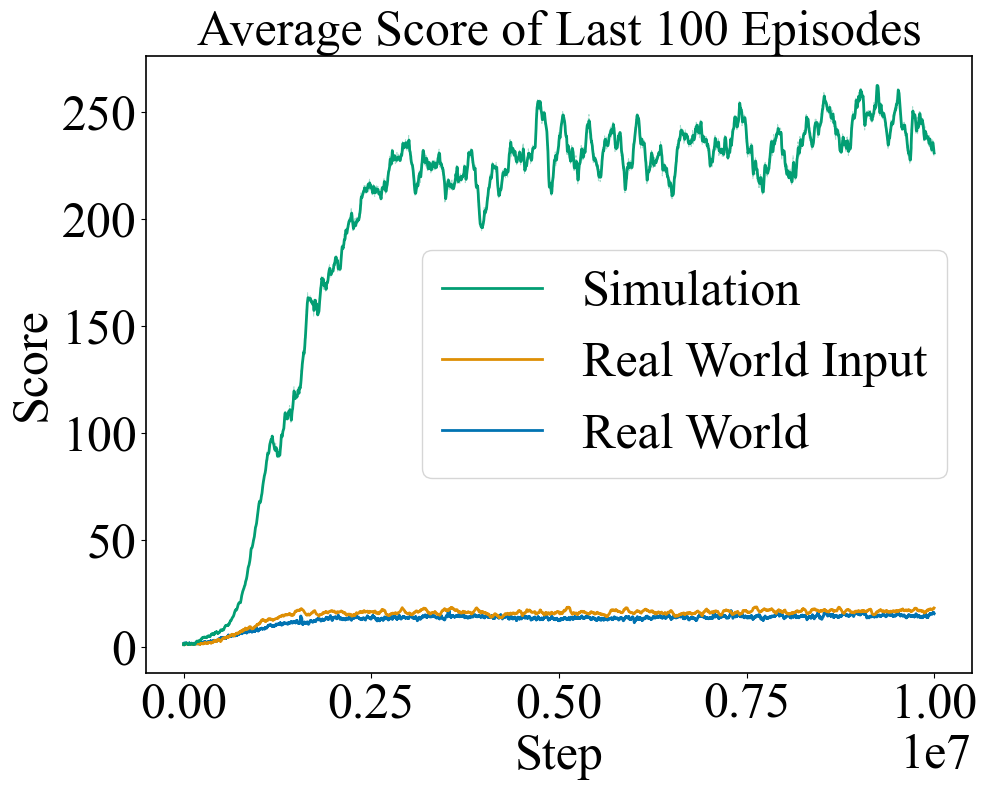

In [231]:
real_world_ep_rew_mean = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260718\\ep_rew_mean.csv"
real_world_input_ep_rew_mean = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_rew_mean.csv"
simulation_ep_rew_mean = "C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_rew_mean.csv"

keys = [real_world_ep_rew_mean, real_world_input_ep_rew_mean, simulation_ep_rew_mean]

legend_map = {
    real_world_ep_rew_mean: "Real World",
    real_world_input_ep_rew_mean: "Real World Input",
    simulation_ep_rew_mean: "Simulation",
}

data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    title="Average Score of Last 100 Episodes",
    x_label="Step",
    y_label="Score",
    figsize=(10, 8),
    window_size=10,
    save_path='three_system',
    is_legend=True,
    # skip_color = 1,
    fontsize_title=36,
    fontsize_label=36,
    fontsize_legend=36,
    fontsize_tick=36,
)

real csv file C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260718\ep_rew_mean.csv
real csv file C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_rew_mean.csv
skip_color: 1
{'C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260718\\ep_rew_mean.csv': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_rew_mean.csv': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)}
key: C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260718\ep_rew_mean.csv
key: C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_rew_mean.csv


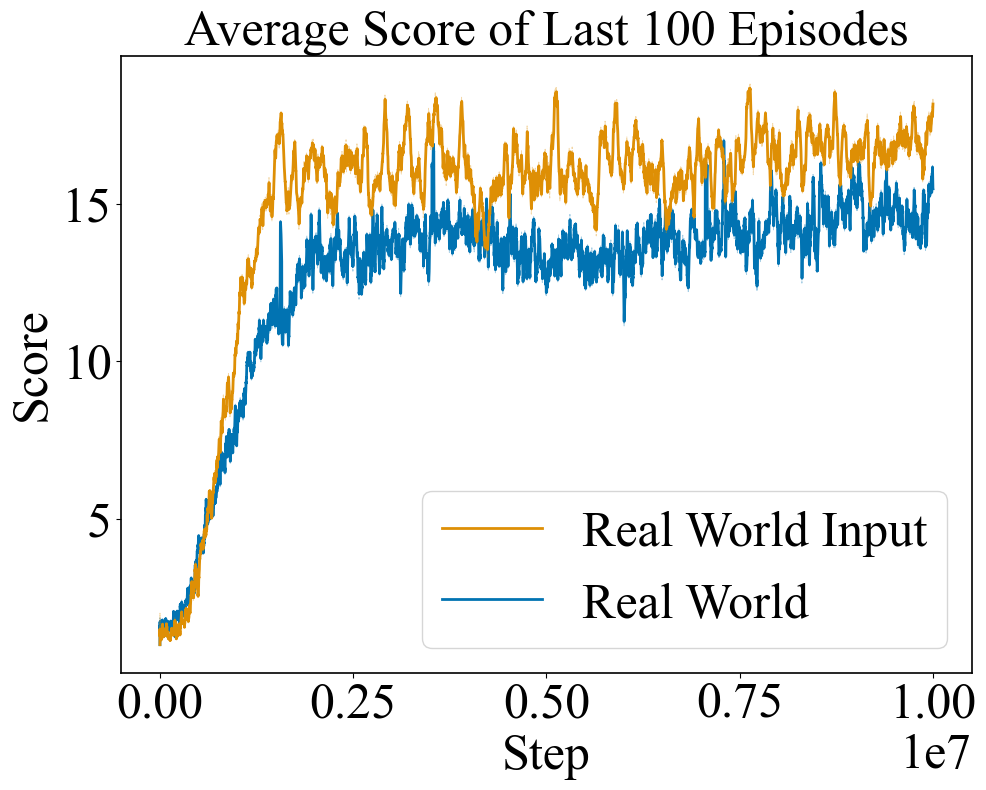

In [232]:
keys = [real_world_ep_rew_mean, real_world_input_ep_rew_mean]

legend_map = {
    real_world_ep_rew_mean: "Real World",
    real_world_input_ep_rew_mean: "Real World Input",
}
data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    # colors=["green", "dodgerblue"],
    title="Average Score of Last 100 Episodes",
    x_label="Step",
    y_label="Score",
    figsize=(10, 8),
    window_size=10,
    save_path='two_system',
    is_legend=True,
    skip_color=1,
    fontsize_title=36,
    fontsize_label=36,
    fontsize_legend=36,
    fontsize_tick=36,
)

## Time Cost Comparison (Bar Chart)

Compare the **total wall-clock time consumed** by each setting across equal-length step intervals.

In [233]:
def plot_time_cost_bar(
    metric: str = "ep_len_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    # x_label: str = "Time Cost (s)",
    x_label: str = " ",
    y_label: str = " ",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
    horizontal = True,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    print(f"legend_map: {legend_map}")
    print(f"legend_map keys: {list(legend_map.keys())}")
    if keys is None:
        if horizontal:
            keys=list(legend_map.keys())
        else:
            keys=list(legend_map.keys())[::-1]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    total_times = {}
    for key in keys:
        print("key: ", key)
        df = read_rl_csv_full(metric, key, base_dir)
        total_times[key] = (df["Wall time"].max() - df["Wall time"].min())/3600/24

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        # color_palette = sns.color_palette(color_palette, n_colors=len(algorithms)+1)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        colors = dict(zip(keys, color_palette))
        print(colors)
    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    print(labels)

    values = [total_times[k] for k in keys]
    print(values)
    # bar_colors = [colors[i % len(colors)] for i in range(len(keys))]
    if horizontal:
        bar_colors = [colors[key] for key in keys]
    else:
        bar_colors = [colors[key] for key in keys][::-1]
    print(f"bar_colors: {bar_colors}")

    if horizontal:
        figsize = (5, 5)
        x_label = "Days"
    else:
        figsize = (5, 5)
        y_label = "Days"
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    # x = range(len(labels))
    if horizontal:
        bars = ax.barh(labels, values, height = 0.7, color=bar_colors, edgecolor="white", linewidth=0.5)
        # bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlim(right=max(values) * 1.1)
    else:
        bars = ax.bar(labels, values, width =0.7, color=bar_colors)
        ax.bar_label(bars, padding=3, fontsize=18, fmt="%.1f")
        ax.set_ylim(top=max(values) * 1.1)
        # ax.set_xticklabels(labels, rotation=90)
        # plt.xticks(rotation=90) 

    # ax.set_title(title, fontsize=_title_fs, pad=8)
    # ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    # ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    
    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()


In [234]:
def read_rl_csv_full(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """Read RL CSV with Wall time, Step, Value columns."""
    # path = Path(base_dir) / metric / f"{key}.csv"
    path = f"{key}"
    print(f"read_rl_csv_full path: {path}")
    df = pd.read_csv(path)
    return df[["Wall time", "Step", "Value"]].reset_index(drop=True)

legend_map: {'C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260718\\ep_len_mean.csv': 'R/W', 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_len_mean.csv': 'R/I', 'C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_len_mean.csv': 'Sim'}
legend_map keys: ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260718\\ep_len_mean.csv', 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_len_mean.csv', 'C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_len_mean.csv']
key:  C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_len_mean.csv
read_rl_csv_full path: C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_len_mean.csv
key:  C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_len_mean.csv
read_rl_csv_full path: C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_len_mean.csv
key:  C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260718\ep_len_me

C:\Users\rongp\AppData\Local\Temp\ipykernel_44356\487126968.py:108: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


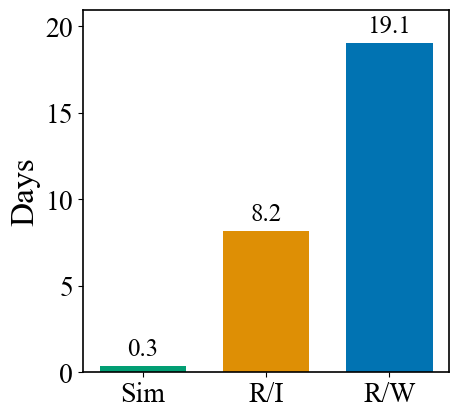

In [235]:
real_world_ep_len_mean = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260718\\ep_len_mean.csv"
real_world_input_ep_len_mean = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_len_mean.csv"
simulation_ep_len_mean = "C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_len_mean.csv"

keys = [real_world_ep_len_mean, real_world_input_ep_len_mean, simulation_ep_len_mean]

legend_map = {
    real_world_ep_len_mean: "R/W",
    real_world_input_ep_len_mean: "R/I",
    simulation_ep_len_mean: "Sim",
}

plot_time_cost_bar(
    metric="ep_len_mean",
    # keys=["real_world", "simulation_with_real_world_input", "simulation"],
    legend_map=legend_map,
    base_dir=".",
    # colors=["red", "green", "dodgerblue"],
    title="Training Time",
    # title="Total Training Time for 10 Million Steps",
    # y_label="Days",
    # figsize=(4, 8),
    save_path="time_cost_bar",
    horizontal = False,
)

In [236]:
def plot_maximum_score_bar(
    metric: str = "ep_rew_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    # x_label: str = "Time Cost (s)",
    x_label: str = " ",
    y_label: str = " ",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
    horizontal = True,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    print(f"legend_map: {legend_map}")
    if keys is None:
        if horizontal:
            keys=list(legend_map.keys())
        else:
            keys=list(legend_map.keys())[::-1]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    max_mean_score = {}
    # i = 0
    for key in keys:
        print("key: ", key)
        df = read_rl_csv_full(metric, key, base_dir)
        max_mean_score[key] = df["Value"].max()
        # if i == 0:
        #     max_mean_score[key] = 335
        # # i += 1
        # if i == 1:
        #     max_mean_score[key] = 30.4
        # if i == 2:
        #     max_mean_score[key] = 12.5
        # i += 1

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        # color_palette = sns.color_palette(color_palette, n_colors=len(algorithms)+1)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        colors = dict(zip(keys, color_palette))
        print(colors)
    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    print(labels)
    values = [max_mean_score[k] for k in keys]
    # bar_colors = [colors[i % len(colors)] for i in range(len(keys))]
    bar_colors = [colors[key] for key in keys][::-1]
    print(f"bar_colors: {bar_colors}")

    if horizontal:
        figsize = (8, 4)
        x_label = "Scores"
    else:
        figsize = (5, 5)
        y_label = "Scores"
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    # x = range(len(labels))
    if horizontal:
        bars = ax.barh(labels, values, color=bar_colors, edgecolor="white", linewidth=0.5)
        # bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlim(right=max(values) * 1.1)
    else:
        bars = ax.bar(labels, values, width=0.7, color=bar_colors)
        ax.bar_label(bars, padding=3, fontsize=18, fmt="%.1f")
        ax.set_ylim(top=max(values) * 1.1)
        # ax.set_xticklabels(labels, rotation=90)
        # plt.xticks(rotation=90)

    # ax.set_title(title, fontsize=_title_fs, pad=8)
    # ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    # ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    # plt.subplots_adjust(bottom=0.05)

    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
        # fig.savefig(f"{save_path}.png", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

C:\Users\rongp\AppData\Local\Temp\ipykernel_44356\3918850776.py:113: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


legend_map: {'C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260718\\ep_rew_mean.csv': 'R/W', 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_rew_mean.csv': 'R/I', 'C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_rew_mean.csv': 'Sim'}
key:  C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_rew_mean.csv
read_rl_csv_full path: C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_rew_mean.csv
key:  C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_rew_mean.csv
read_rl_csv_full path: C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_rew_mean.csv
key:  C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260718\ep_rew_mean.csv
read_rl_csv_full path: C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260718\ep_rew_mean.csv
{'C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_rew_mean.csv': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'C:\\GitHub\\data_and_

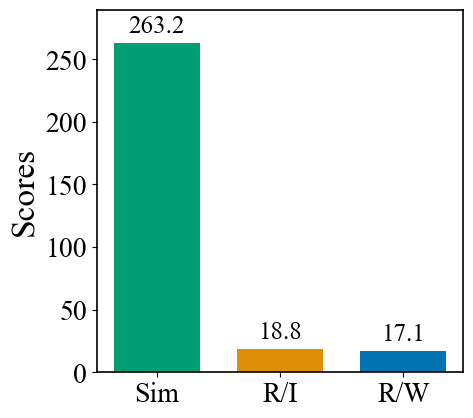

In [237]:
real_world_ep_rew_mean = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260718\\ep_rew_mean.csv"
real_world_input_ep_rew_mean = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_rew_mean.csv"
simulation_ep_rew_mean = "C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_rew_mean.csv"

keys = [real_world_ep_rew_mean, real_world_input_ep_rew_mean, simulation_ep_rew_mean]

legend_map = {
    real_world_ep_rew_mean: "R/W",
    real_world_input_ep_rew_mean: "R/I",
    simulation_ep_rew_mean: "Sim",
}

plot_maximum_score_bar(
    metric="ep_rew_mean",
    # keys=["real_world", "simulation_with_real_world_input", "simulation"],
    legend_map=legend_map,
    base_dir=".",
    # colors=["red", "green", "dodgerblue"],
    title="Maximum Score",
    # y_label="Days",
    # figsize=(4, 8),
    save_path="max_score_bar",
    horizontal = False,
)

## Data Processing to find the best model

In [238]:
import time
import numpy as np

from evaluation.atari_data import get_human_normalized_score, get_env_id
from evaluation import library as rly
from evaluation import metrics
from evaluation import plot_utils

import tkinter as tk

import os

import gymnasium as gym

import argparse
from distutils.util import strtobool

import ale_py
gym.register_envs(ale_py)
# gym.pprint_registry()


In [239]:
gym_id = "BreakoutNoFrameskip-v4"

In [240]:
env_id = get_env_id(gym_id)
print(f"env_id: {env_id}")

env_id: breakout


## Three Systems Comparison — Interval Estimates (Median / IQM / Mean)

In [241]:
# ── Plotting function ────────────────────────────────────────────────────────
def plot_existing_data_interval_estimates(
    point_estimates,
    interval_estimates,
    metric='Median',
    legend_map=legend_map,
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """

    # keys=['real world system', 'real world input', 'simulation']
    keys=['real world system', 'real world input', 'simulation', 'change']
    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  22)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  22)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 22)

    _DEFAULT_COLOURS = {
        'change':        '#2BAAAB',
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
        color_palette='colorblind'
        # color_palette = sns.color_palette(color_palette, n_colors=len(hns_scores.keys()))
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        # colours = dict(zip(hns_scores.keys(), color_palette))
        colours = dict(zip(keys, color_palette))
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    for yi, label in enumerate(system_order):
        pt = point_estimates[label]
        lo, hi = interval_estimates[label]
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')

    print("legend_map: ", legend_map)
    print("keys :", keys)

    labels = list(legend_map.values())
    print("labels: ", labels)
    ax.set_yticks(range(len(system_order)))
    # ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_yticklabels(labels, fontsize=_tick_fs)
    # ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    # ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.pdf', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()

In [242]:
aggregate_scores = {
    "real world system": np.array([0.49652778,      0.49444444, 0.49027778, 0.50972222]), 
    "real world input": np.array([0.67013889, 0.65138889, 0.69097222, 0.33489583]), 
    "simulation": np.array([11.60763889, 11.60763889, 11.32048611, 0.])}
aggregate_score_cis = {
        "real world system": np.array([[0.46180556, 0.45416667, 0.45590278, 0.47569444],
                                       [0.53125, 0.52986111, 0.52430556, 0.54409722]]), 
        "real world input": np.array([[0.60069444, 0.60277778, 0.64201389, 0.29513889],
                                      [0.70486111, 0.70416667, 0.74271701, 0.37430556]]), 
        "simulation": np.array([[11.08680556, 11.32222222, 10.92083333, 0.],
                                [11.60763889, 12.01388889, 11.70381944, 0.]])}

# Simulation
# 11.08681, 11.32222, 10.92083, 0.
# 11.60764, 11.60764, 11.32049, 0.
# 11.60764, 12.01389, 11.70382, 0.

# Real world input
# 0.60069, 0.60278, 0.64201, 0.29514
# 0.67014, 0.65139, 0.69097, 0.33490
# 0.70486, 0.70417, 0.74272, 0.37431

# Real world
# 0.46181, 0.45417, 0.45590, 0.47569
# 0.49653, 0.49444, 0.49028, 0.50972
# 0.53125, 0.52986, 0.52431, 0.54410

In [243]:
SYSTEM_ORDER = ['real world system', 'real world input', 'simulation']
legend_map = {
    "real world system": "R/W",
    "real world input": "R/I",
    "simulation": "Sim",
}

In [244]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")

aggregate_scores_median: type: <class 'dict'>, data: {'real world system': array([0.49652778]), 'real world input': array([0.67013889]), 'simulation': array([11.60763889])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world system': array([[0.46180556],
       [0.53125   ]]), 'real world input': array([[0.60069444],
       [0.70486111]]), 'simulation': array([[11.08680556],
       [11.60763889]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'R/I', 'Sim']


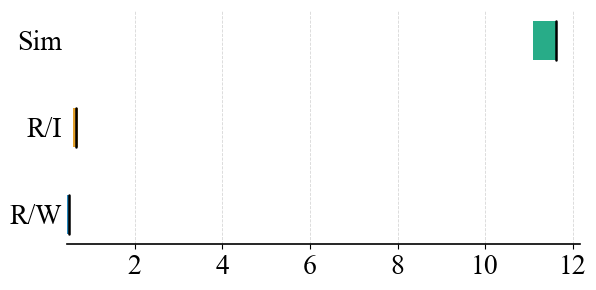

In [245]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_median',
)

In [246]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world system': array([0.49444444]), 'real world input': array([0.65138889]), 'simulation': array([11.60763889])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world system': array([[0.45416667],
       [0.52986111]]), 'real world input': array([[0.60277778],
       [0.70416667]]), 'simulation': array([[11.32222222],
       [12.01388889]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'R/I', 'Sim']


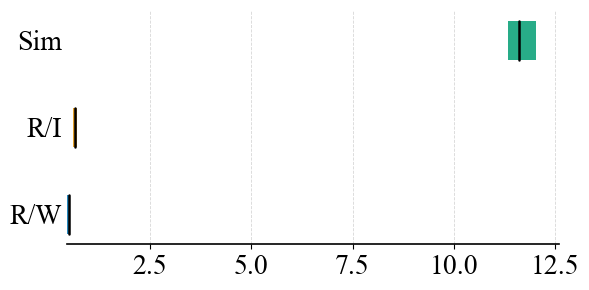

In [247]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_iqm',
)

In [248]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world system': array([0.49027778]), 'real world input': array([0.69097222]), 'simulation': array([11.32048611])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world system': array([[0.45590278],
       [0.52430556]]), 'real world input': array([[0.64201389],
       [0.74271701]]), 'simulation': array([[10.92083333],
       [11.70381944]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'R/I', 'Sim']


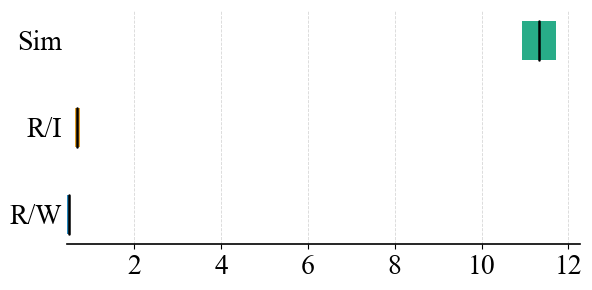

In [249]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_mean',
)

In [250]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world system': array([0.50972222]), 'real world input': array([0.33489583]), 'simulation': array([0.])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world system': array([[0.47569444],
       [0.54409722]]), 'real world input': array([[0.29513889],
       [0.37430556]]), 'simulation': array([[0.],
       [0.]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'R/I', 'Sim']


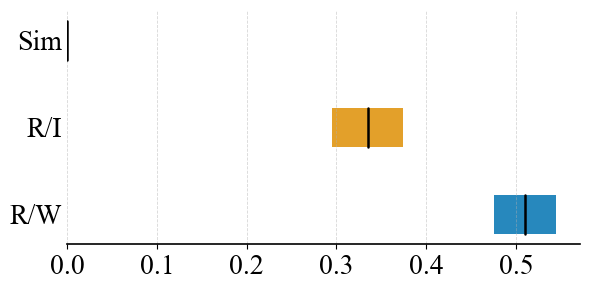

In [251]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_optimality_gap',
)

In [252]:
aggregate_scores = {
    "real world input": np.array([0.67013889, 0.65138889, 0.69097222, 0.33489583]), 
    "simulation": np.array([0.01041667, 0.00625,    0.03159722, 0.96840278])}
aggregate_score_cis = {
        "real world input": np.array([[0.60069444, 0.60347222, 0.64201389, 0.29513889],
                                      [0.70486111, 0.70416667, 0.74271701, 0.37430556]]), 
        "simulation": np.array([[-0.02430556, -0.00694444,  0.01527778,  0.95034722],
                                [0.01041667,  0.02361111,  0.04965278,  0.98472222]])}
print(f"aggregate_scores: type: {type(aggregate_scores)}, data: {aggregate_scores}")
print(f"aggregate_scores: type: {type(aggregate_score_cis)}, data: {aggregate_score_cis}")

# Simulation in the real world input system
# -0.02431, -0.00694,  0.01528,  0.95035
# 0.01042, 0.00625,    0.03160, 0.96840
# 0.01042,  0.02361,  0.04965,  0.98472

# Real world input
# 0.60069, 0.60278, 0.64201, 0.29514
# 0.67014, 0.65139, 0.69097, 0.33490
# 0.70486, 0.70417, 0.74272, 0.37431

aggregate_scores: type: <class 'dict'>, data: {'real world input': array([0.67013889, 0.65138889, 0.69097222, 0.33489583]), 'simulation': array([0.01041667, 0.00625   , 0.03159722, 0.96840278])}
aggregate_scores: type: <class 'dict'>, data: {'real world input': array([[0.60069444, 0.60347222, 0.64201389, 0.29513889],
       [0.70486111, 0.70416667, 0.74271701, 0.37430556]]), 'simulation': array([[-0.02430556, -0.00694444,  0.01527778,  0.95034722],
       [ 0.01041667,  0.02361111,  0.04965278,  0.98472222]])}


In [253]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")


aggregate_scores_median: type: <class 'dict'>, data: {'real world input': array([0.67013889]), 'simulation': array([0.01041667])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world input': array([[0.60069444],
       [0.70486111]]), 'simulation': array([[-0.02430556],
       [ 0.01041667]])}


In [254]:
SYSTEM_ORDER = ['real world input', 'simulation']
legend_map = {
    "real world input": "R/I",
    "simulation": "Sim",
}

legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/I', 'Sim']


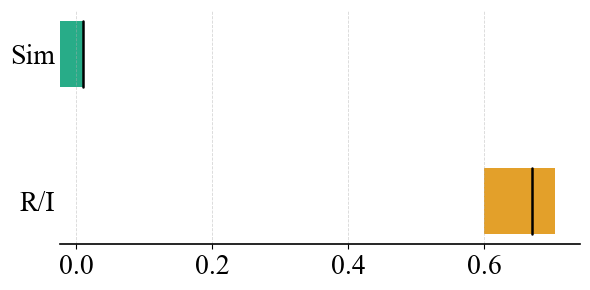

In [255]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_input_system_median',
)

In [256]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world input': array([0.65138889]), 'simulation': array([0.00625])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world input': array([[0.60347222],
       [0.70416667]]), 'simulation': array([[-0.00694444],
       [ 0.02361111]])}


legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/I', 'Sim']


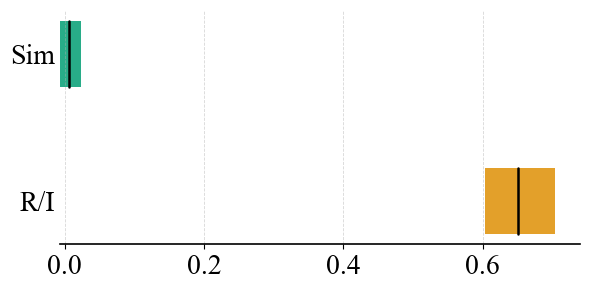

In [257]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_input_system_iqm',
)

In [258]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world input': array([0.69097222]), 'simulation': array([0.03159722])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world input': array([[0.64201389],
       [0.74271701]]), 'simulation': array([[0.01527778],
       [0.04965278]])}


legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/I', 'Sim']


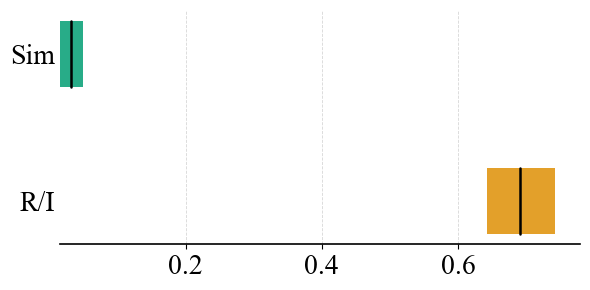

In [259]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_input_system_mean',
)

In [260]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world input': array([0.33489583]), 'simulation': array([0.96840278])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world input': array([[0.29513889],
       [0.37430556]]), 'simulation': array([[0.95034722],
       [0.98472222]])}


legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/I', 'Sim']


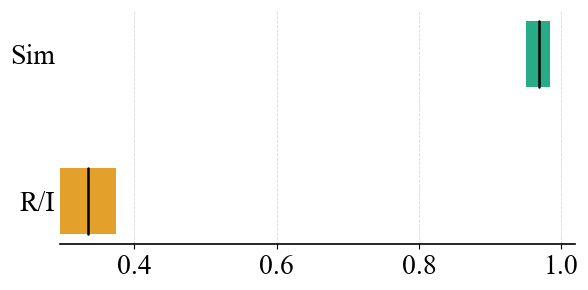

In [261]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_input_system_optimality_gap',
)

In [262]:
aggregate_scores = {
    "real world system": np.array([0.49652778,      0.49444444, 0.49027778, 0.50972222]), 
    "simulation": np.array([0.01041667, 0.02083333,    0.01493056,  0.98506944])}
aggregate_score_cis = {
        "real world system": np.array([[0.46180556, 0.45416667, 0.45590278, 0.47569444],
                                       [0.53125, 0.52986111, 0.52430556, 0.54409722]]), 
        "simulation": np.array([[0.01041667, 0.01319444,    0.00659722,  0.97708333],
                                [0.02777778,  0.02777778,  0.02291667,  0.99340278]])}

# Simulation in the real world system
# 0.01042, 0.01319, 0.00660, 0.97708
# 0.01042, 0.02083, 0.01493, 0.98507
# 0.02778, 0.02778, 0.02292, 0.99340

# Real world
# 0.46181, 0.45417, 0.45590, 0.47569
# 0.49653, 0.49444, 0.49028, 0.50972
# 0.53125, 0.52986, 0.52431, 0.54410

In [263]:
SYSTEM_ORDER = ['real world system', 'simulation']
legend_map = {
    "real world system": "R/W",
    "simulation": "Sim",
}

In [264]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")

aggregate_scores_median: type: <class 'dict'>, data: {'real world system': array([0.49652778]), 'simulation': array([0.01041667])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world system': array([[0.46180556],
       [0.53125   ]]), 'simulation': array([[0.01041667],
       [0.02777778]])}


legend_map:  {'real world system': 'R/W', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'Sim']


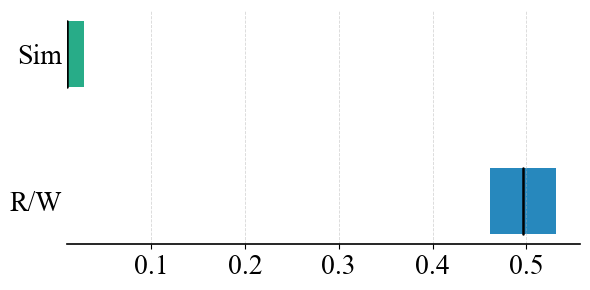

In [265]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_system_median',
)

In [266]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world system': array([0.49444444]), 'simulation': array([0.02083333])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world system': array([[0.45416667],
       [0.52986111]]), 'simulation': array([[0.01319444],
       [0.02777778]])}


legend_map:  {'real world system': 'R/W', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'Sim']


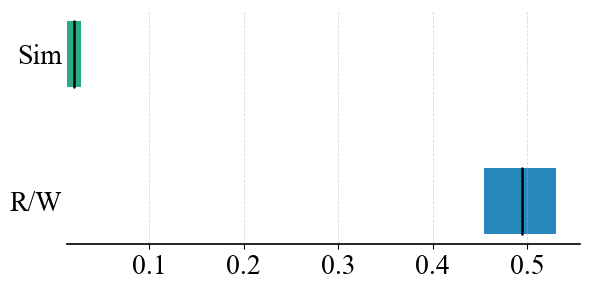

In [267]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_system_iqm',
)

In [268]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world system': array([0.49027778]), 'simulation': array([0.01493056])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world system': array([[0.45590278],
       [0.52430556]]), 'simulation': array([[0.00659722],
       [0.02291667]])}


legend_map:  {'real world system': 'R/W', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'Sim']


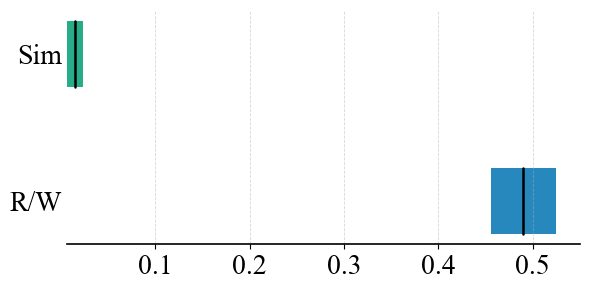

In [269]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_system_mean',
)

In [270]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world system': array([0.50972222]), 'simulation': array([0.98506944])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world system': array([[0.47569444],
       [0.54409722]]), 'simulation': array([[0.97708333],
       [0.99340278]])}


legend_map:  {'real world system': 'R/W', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'Sim']


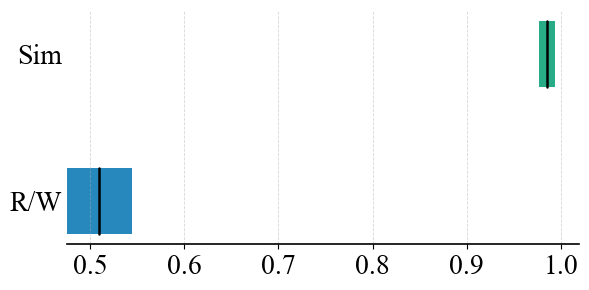

In [271]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_system_optimality_gap',
)

## Environment Change Impact

In [272]:
aggregate_scores = {
    "real world system": np.array([0.49652778,      0.49444444, 0.49027778, 0.50972222]), 
    "change": np.array([0.01041667, 0.02291667, 0.02916667, 0.97083333])}
aggregate_score_cis = {
        "real world system": np.array([[0.46180556, 0.45416667, 0.45590278, 0.47569444],
                                       [0.53125, 0.52986111, 0.52430556, 0.54409722]]), 
        "change": np.array([[0.01041667, 0.01597222, 0.021875, 0.96319444],
                            [0.04513889, 0.02986111, 0.03680556, 0.978125]])}

# after change
# 0.01042, 0.01597, 0.02188, 0.96319
# 0.01042, 0.02292, 0.02917, 0.97083
# 0.04514, 0.02986, 0.03681, 0.97813

# Real world
# 0.46181, 0.45417, 0.45590, 0.47569
# 0.49653, 0.49444, 0.49028, 0.50972
# 0.53125, 0.52986, 0.52431, 0.54410

In [273]:
SYSTEM_ORDER = ['real world system', 'change']
legend_map = {
    "real world system": "R/W",
    "change": "A/C",
}

In [274]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")

aggregate_scores_median: type: <class 'dict'>, data: {'real world system': array([0.49652778]), 'change': array([0.01041667])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world system': array([[0.46180556],
       [0.53125   ]]), 'change': array([[0.01041667],
       [0.04513889]])}


legend_map:  {'real world system': 'R/W', 'change': 'A/C'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'A/C']


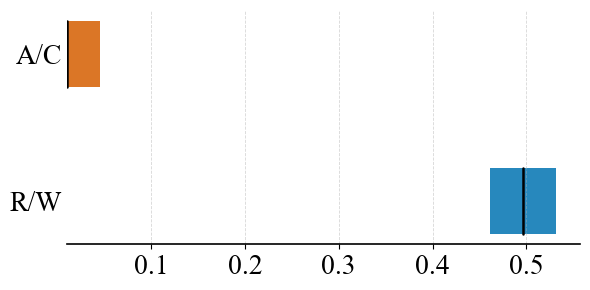

In [275]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_system_change_median',
)

In [276]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world system': array([0.49444444]), 'change': array([0.02291667])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world system': array([[0.45416667],
       [0.52986111]]), 'change': array([[0.01597222],
       [0.02986111]])}


legend_map:  {'real world system': 'R/W', 'change': 'A/C'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'A/C']


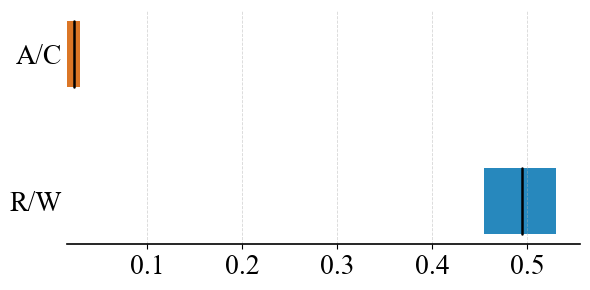

In [277]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_system_change_iqm',
)

In [278]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world system': array([0.49027778]), 'change': array([0.02916667])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world system': array([[0.45590278],
       [0.52430556]]), 'change': array([[0.021875  ],
       [0.03680556]])}


legend_map:  {'real world system': 'R/W', 'change': 'A/C'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'A/C']


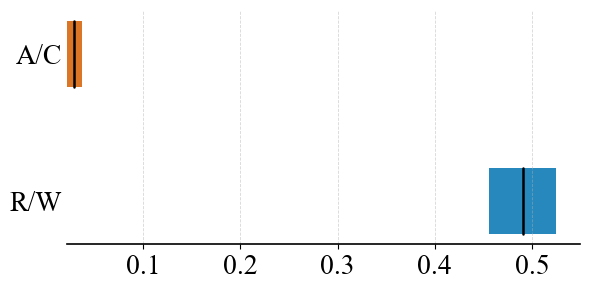

In [279]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_system_change_mean',
)

In [280]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world system': array([0.50972222]), 'change': array([0.97083333])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world system': array([[0.47569444],
       [0.54409722]]), 'change': array([[0.96319444],
       [0.978125  ]])}


legend_map:  {'real world system': 'R/W', 'change': 'A/C'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/W', 'A/C']


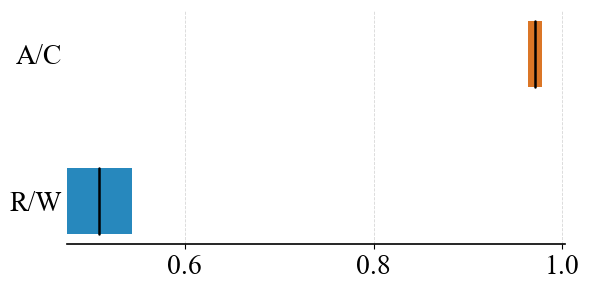

In [281]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_system_change_optimality_gap',
)

In [282]:
aggregate_scores = {
    "real world input": np.array([0.67013889, 0.65138889, 0.69097222, 0.33489583]), 
    "change": np.array([0.01041667, 0.01736111, 0.01909722, 0.98090278])}
aggregate_score_cis = {
        "real world input": np.array([[0.60069444, 0.60347222, 0.64201389, 0.29513889],
                                      [0.70486111, 0.70416667, 0.74271701, 0.37430556]]), 
        "change": np.array([[0.01041667, 0.00694444, 0.01180556, 0.97291667],
                            [0.01041667, 0.02361111, 0.02708333, 0.98819444]])}
print(f"aggregate_scores: type: {type(aggregate_scores)}, data: {aggregate_scores}")
print(f"aggregate_scores: type: {type(aggregate_score_cis)}, data: {aggregate_score_cis}")

# after change
# 0.01042, 0.00694, 0.01181, 0.97292
# 0.01042, 0.01736, 0.01910, 0.98090
# 0.01042, 0.02361, 0.02708, 0.98819

# Real world input
# 0.60069, 0.60278, 0.64201, 0.29514
# 0.67014, 0.65139, 0.69097, 0.33490
# 0.70486, 0.70417, 0.74272, 0.37431

aggregate_scores: type: <class 'dict'>, data: {'real world input': array([0.67013889, 0.65138889, 0.69097222, 0.33489583]), 'change': array([0.01041667, 0.01736111, 0.01909722, 0.98090278])}
aggregate_scores: type: <class 'dict'>, data: {'real world input': array([[0.60069444, 0.60347222, 0.64201389, 0.29513889],
       [0.70486111, 0.70416667, 0.74271701, 0.37430556]]), 'change': array([[0.01041667, 0.00694444, 0.01180556, 0.97291667],
       [0.01041667, 0.02361111, 0.02708333, 0.98819444]])}


In [283]:
SYSTEM_ORDER = ['real world input', 'change']
legend_map = {
    "real world input": "R/I",
    "change": "A/C",
}

In [284]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")

aggregate_scores_median: type: <class 'dict'>, data: {'real world input': array([0.67013889]), 'change': array([0.01041667])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world input': array([[0.60069444],
       [0.70486111]]), 'change': array([[0.01041667],
       [0.01041667]])}


legend_map:  {'real world input': 'R/I', 'change': 'A/C'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/I', 'A/C']


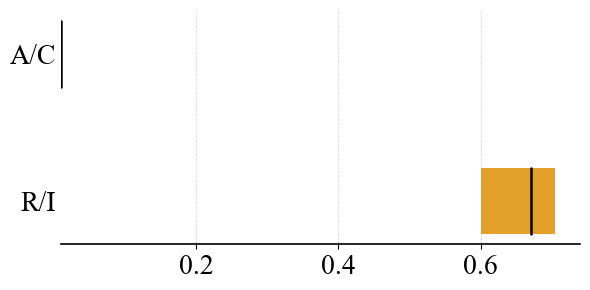

In [285]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_input_change_median',
)

In [286]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world input': array([0.65138889]), 'change': array([0.01736111])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world input': array([[0.60347222],
       [0.70416667]]), 'change': array([[0.00694444],
       [0.02361111]])}


legend_map:  {'real world input': 'R/I', 'change': 'A/C'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/I', 'A/C']


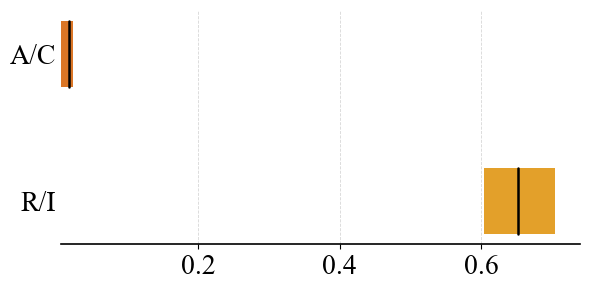

In [287]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_input_change_iqm',
)

In [288]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world input': array([0.69097222]), 'change': array([0.01909722])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world input': array([[0.64201389],
       [0.74271701]]), 'change': array([[0.01180556],
       [0.02708333]])}


legend_map:  {'real world input': 'R/I', 'change': 'A/C'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/I', 'A/C']


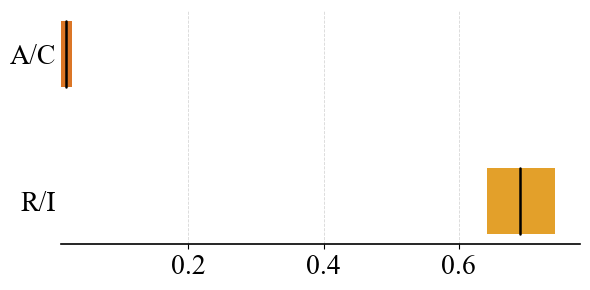

In [289]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_input_change_mean',
)

In [290]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world input': array([0.33489583]), 'change': array([0.98090278])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world input': array([[0.29513889],
       [0.37430556]]), 'change': array([[0.97291667],
       [0.98819444]])}


legend_map:  {'real world input': 'R/I', 'change': 'A/C'}
keys : ['real world system', 'real world input', 'simulation', 'change']
labels:  ['R/I', 'A/C']


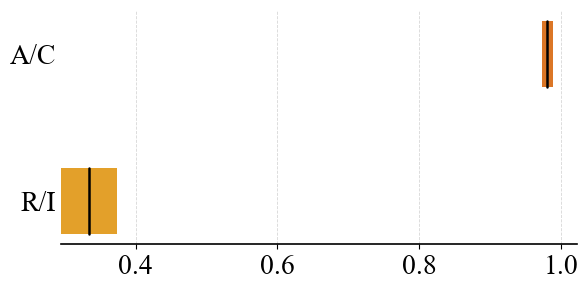

In [291]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_input_change_optimality_gap',
)

In [292]:
# ── Plotting function ────────────────────────────────────────────────────────
def plot_existing_data_gap_estimates(
    point_estimates,
    interval_estimates,
    metric='Median',
    legend_map=legend_map,
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    top_bar_y = len(system_order) - 1
    arrow_y1 = top_bar_y + 2.25 
    text_y1 = arrow_y1 + 0.25
    arrow_y2 = top_bar_y + 1.25
    text_y2 = arrow_y2 + 0.25
    gap_colour = '#4D4D4D'
    
    # keys=['real world system', 'real world input', 'simulation']
    keys=['real world system', 'real world input', 'simulation', 'change']
    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  22)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  22)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 22)

    _DEFAULT_COLOURS = {
        'change':        '#2BAAAB',
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
        color_palette='colorblind'
        # color_palette = sns.color_palette(color_palette, n_colors=len(hns_scores.keys()))
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        # colours = dict(zip(hns_scores.keys(), color_palette))
        colours = dict(zip(keys, color_palette))
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    i = 0

    for yi, label in enumerate(system_order):
        pt = point_estimates[label]
        lo, hi = interval_estimates[label]
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')
        # Dashed guide extending upward
        if i == 0:
            # arrow_y = top_bar_y
            arrow_y = arrow_y2
        if i == 1:
            arrow_y = arrow_y2
        if i == 2:
            arrow_y = arrow_y2
        ax.plot(
            [pt, pt],
            [yi + bar_height / 2, arrow_y],
            color=gap_colour,
            linewidth=1.0,
            linestyle='--',
            alpha=0.7,
            zorder=1,
        )
        i += 1

    i = 0
    for yi, label in enumerate(system_order):
        if i == 0:
            # x1 = point_estimates[label]
            x0 = np.mean(point_estimates[label])
            print(f"x0: {x0}")
        if i == 1:
            # x1 = point_estimates[label]
            x1 = np.mean(point_estimates[label])
            print(f"x1: {x1}")
        if i == 2:
            # x2 = point_estimates[label]
            x2 = np.mean(point_estimates[label])
            print(f"x2: {x2}")
        i += 1
    
    ax.errorbar(
        x=(x0 + x2) / 2,
        y=arrow_y2,
        xerr=abs(x2 - x0) / 2,
        fmt='none',
        ecolor=gap_colour,
        elinewidth=1.5,
        capsize=5,
        capthick=1.5,
        zorder=3,
    )
    
    gap1 = abs(x2 - x0)
    
    ax.text(
        (x0 + x2) / 2,
        arrow_y2 + 0.20,
        f'Sim-to-Real gap ({gap1:.1f})',
        color=gap_colour,
        ha='center',
        va='bottom',
        fontsize=_label_fs,
    )    
    # Extend the plotting area upward
    ax.set_ylim(-0.5, text_y2 + 0.55)
    
    labels = list(legend_map.values())
    print("labels: ", labels)
    ax.set_yticks(range(len(system_order)))
    # ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_yticklabels(labels, fontsize=_tick_fs)
    # ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    # ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.pdf', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()


In [293]:
aggregate_scores = {
    "real world system": np.array([0.01041667, 0.02083333,    0.01493056,  0.98506944]), 
    "real world input": np.array([0.01041667, 0.00625,    0.03159722, 0.96840278]), 
    "simulation": np.array([11.60763889, 11.60763889, 11.32048611, 0.])}
aggregate_score_cis = {
        "real world system": np.array([[0.01041667, 0.01319444,    0.00659722,  0.97708333],
                                        [0.02777778,  0.02777778,  0.02291667,  0.99340278]]), 
        "real world input": np.array([[-0.02430556, -0.00694444,  0.01527778,  0.95034722],
                                        [0.01041667,  0.02361111,  0.04965278,  0.98472222]]), 
        "simulation": np.array([[11.08680556, 11.32222222, 10.92083333, 0.],
                                [11.60763889, 12.01388889, 11.70381944, 0.]])}

# Simulation
# 11.08681, 11.32222, 10.92083, 0.
# 11.60764, 11.60764, 11.32049, 0.
# 11.60764, 12.01389, 11.70382, 0.

# Simulation in the real world input system
# -0.02431,-0.00694, 0.01528, 0.95035
#  0.01042, 0.00625, 0.03160, 0.96840
#  0.01042, 0.02361, 0.04965, 0.98472

# Simulation in the real world system
# 0.01042, 0.01319, 0.00660, 0.97708
# 0.01042, 0.02083, 0.01493, 0.98507
# 0.02778, 0.02778, 0.02292, 0.99340

In [294]:
SYSTEM_ORDER = ['real world system', 'real world input', 'simulation']
legend_map = {
    "real world system": "Sim in R/W",
    "real world input": "Sim in R/I",
    "simulation": "Sim in Sim",
}

In [295]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")

aggregate_scores_median: type: <class 'dict'>, data: {'real world system': array([0.01041667]), 'real world input': array([0.01041667]), 'simulation': array([11.60763889])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world system': array([[0.01041667],
       [0.02777778]]), 'real world input': array([[-0.02430556],
       [ 0.01041667]]), 'simulation': array([[11.08680556],
       [11.60763889]])}


x0: 0.01041667
x1: 0.01041667
x2: 11.60763889
labels:  ['Sim in R/W', 'Sim in R/I', 'Sim in Sim']


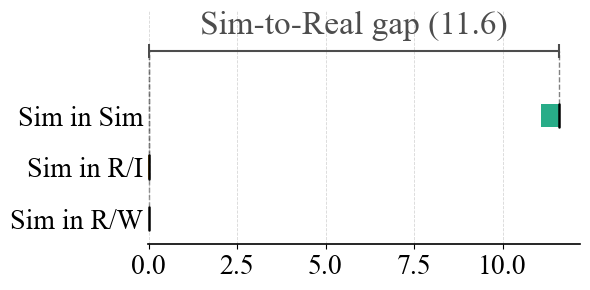

In [296]:
plot_existing_data_gap_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='sim_in_three_systems_median',
)

In [297]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world system': array([0.02083333]), 'real world input': array([0.00625]), 'simulation': array([11.60763889])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world system': array([[0.01319444],
       [0.02777778]]), 'real world input': array([[-0.00694444],
       [ 0.02361111]]), 'simulation': array([[11.32222222],
       [12.01388889]])}


x0: 0.02083333
x1: 0.00625
x2: 11.60763889
labels:  ['Sim in R/W', 'Sim in R/I', 'Sim in Sim']


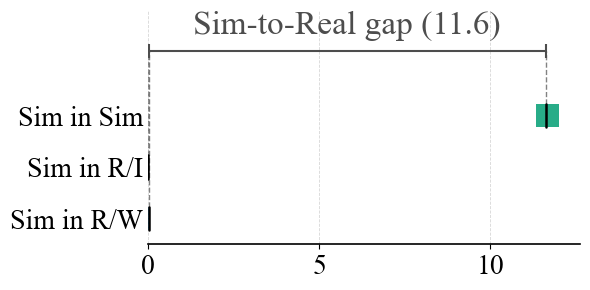

In [298]:
plot_existing_data_gap_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='sim_in_three_systems_iqm',
)

In [299]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world system': array([0.01493056]), 'real world input': array([0.03159722]), 'simulation': array([11.32048611])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world system': array([[0.00659722],
       [0.02291667]]), 'real world input': array([[0.01527778],
       [0.04965278]]), 'simulation': array([[10.92083333],
       [11.70381944]])}


x0: 0.01493056
x1: 0.03159722
x2: 11.32048611
labels:  ['Sim in R/W', 'Sim in R/I', 'Sim in Sim']


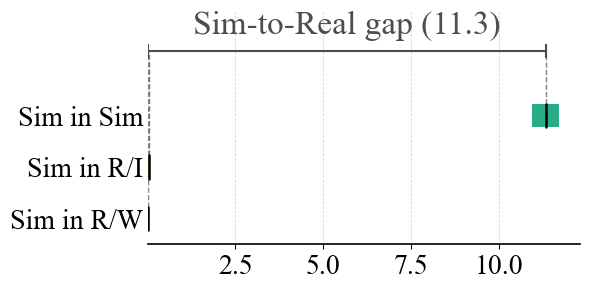

In [300]:
plot_existing_data_gap_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='sim_in_three_systems_mean',
)

In [301]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world system': array([0.98506944]), 'real world input': array([0.96840278]), 'simulation': array([0.])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world system': array([[0.97708333],
       [0.99340278]]), 'real world input': array([[0.95034722],
       [0.98472222]]), 'simulation': array([[0.],
       [0.]])}


x0: 0.98506944
x1: 0.96840278
x2: 0.0
labels:  ['Sim in R/W', 'Sim in R/I', 'Sim in Sim']


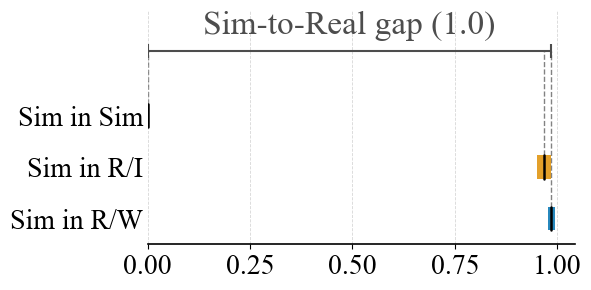

In [302]:
plot_existing_data_gap_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='sim_in_three_systems_optimality_gap',
)